<a href="https://colab.research.google.com/github/Aaish48/ML_Project/blob/main/Sentiment_Analysis_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# 1. Download the dataset via Kagglehub
path = kagglehub.dataset_download("kritanjalijain/amazon-reviews")
print("Path to dataset files:", path)

# 2. Find the train.csv file dynamically
csv_file = None
for root, dirs, files in os.walk(path):
    if "train.csv" in files:
        csv_file = os.path.join(root, "train.csv")
        break

if csv_file is None:
    raise FileNotFoundError("Could not find train.csv in the downloaded dataset.")

# 3. Load a 20,000 row sample of the data (to prevent Colab from crashing)
df = pd.read_csv(csv_file, header=None, names=['Sentiment', 'Title', 'Review'], nrows=20000)

# 4. Fix the Sentiment labels
# Amazon uses 1=Negative, 2=Positive. We map it to 0=Negative, 1=Positive.
df['Sentiment'] = df['Sentiment'].map({1: 0, 2: 1})

# 5. Ensure the 'Review' column is treated as text and handle any blank reviews
df['Review'] = df['Review'].astype(str).fillna("")

print("\nAmazon Dataset loaded successfully!")
print(f"Total reviews loaded: {len(df)}")
print(df[['Sentiment', 'Review']].head()) # Show just the labels and text

100%|██████████| 1.29G/1.29G [00:44<00:00, 31.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2

Amazon Dataset loaded successfully!
Total reviews loaded: 20000
   Sentiment                                             Review
0          1  This sound track was beautiful! It paints the ...
1          1  I'm reading a lot of reviews saying that this ...
2          1  This soundtrack is my favorite music of all ti...
3          1  I truly like this soundtrack and I enjoy video...
4          1  If you've played the game, you know how divine...


In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords list from NLTK
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'don', "don't", 'doesn', "doesn't", 'didn', "didn't", 'wasn', "wasn't", 'wouldn', "wouldn't"}
stop_words = stop_words - negation_words

def preprocess_text(text):
    # Remove punctuation and numbers using Regular Expressions
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove stopwords
    words = text.split()
    clean_words = [word for word in words if word not in stop_words]
    return ' '.join(clean_words)

# Apply the function to our dataset
df['Clean_Review'] = df['Review'].apply(preprocess_text)

print("Preprocessing complete!")
print(df[['Review', 'Clean_Review']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Preprocessing complete!
                                              Review  \
0  This sound track was beautiful! It paints the ...   
1  I'm reading a lot of reviews saying that this ...   
2  This soundtrack is my favorite music of all ti...   
3  I truly like this soundtrack and I enjoy video...   
4  If you've played the game, you know how divine...   

                                        Clean_Review  
0  sound track beautiful paints senery mind well ...  
1  im reading lot reviews saying best game soundt...  
2  soundtrack favorite music time hands intense s...  
3  truly like soundtrack enjoy video game music p...  
4  youve played game know divine music every sing...  


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the data: 75% for training, 25% for testing
X_train, X_test, y_train, y_test = train_test_split(
    df['Clean_Review'], df['Sentiment'], test_size=0.25, random_state=42
)

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# Fit the vectorizer on training data and transform both train and test data
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training data shape: {X_train_tfidf.shape}")
print(f"Testing data shape: {X_test_tfidf.shape}")


Training data shape: (15000, 451174)
Testing data shape: (5000, 451174)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the model
model = MultinomialNB(alpha=0.5)

# Train the model using our TF-IDF data
model.fit(X_train_tfidf, y_train)

print("Naïve Bayes model successfully trained!")

Naïve Bayes model successfully trained!


Model Accuracy: 85.76%


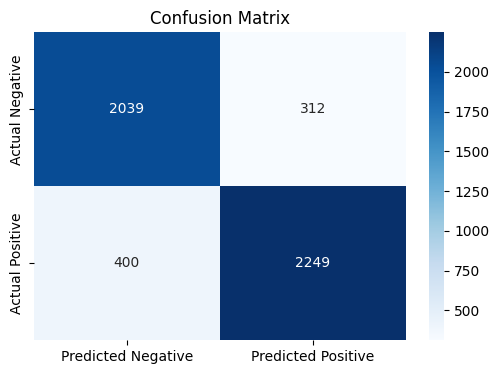

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the Confusion Matrix nicely
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.show()

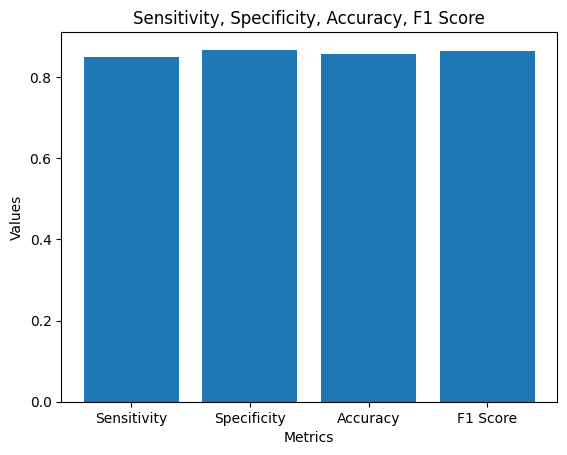

In [ ]:
import matplotlib.pyplot as plt

# Metrics
metrics1 = ['Sensitivity', 'Specificity', 'Accuracy', 'F1 Score']
values1 = [0.849, 0.867, 0.8576, 0.863]

plt.figure()
plt.bar(metrics1, values1)
plt.title("Sensitivity, Specificity, Accuracy, F1 Score")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

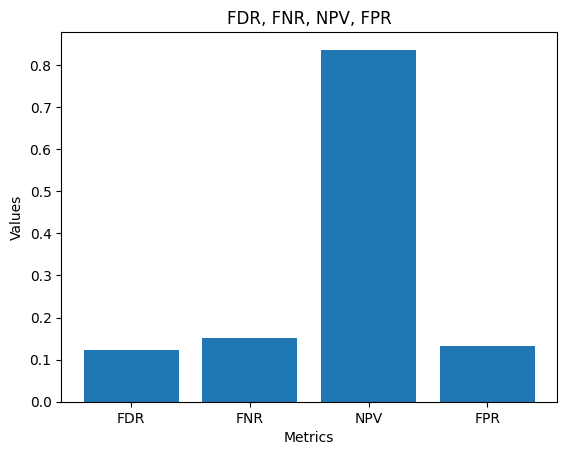

In [ ]:
metrics2 = ['FDR', 'FNR', 'NPV', 'FPR']
values2 = [0.122, 0.151, 0.836, 0.133]

plt.figure()
plt.bar(metrics2, values2)
plt.title("FDR, FNR, NPV, FPR")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

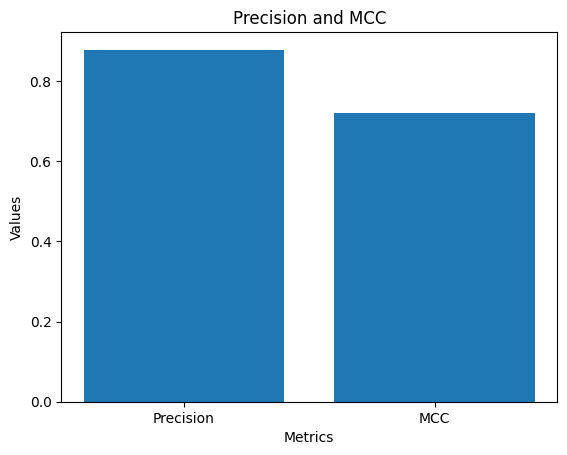

In [ ]:
metrics3 = ['Precision', 'MCC']
values3 = [0.878, 0.72]

plt.figure()
plt.bar(metrics3, values3)
plt.title("Precision and MCC")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()

In [ ]:
import pickle

# Save model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Model and vectorizer saved!")

Model and vectorizer saved!
